In [8]:
import ast
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import matplotlib.font_manager as fm


## Functons and constants

#### Helper functions

In [9]:


def combine_jsons(dir_path):
    files = [f for f in os.listdir(dir_path) if f.endswith('.json')]
    results_data = []

    temperature_bins = [(15, 16), (16, 17), (17, 18), (18, 19), (19, 20), (20, 21), (21, 22), (22, 23), (23, 24), (24, 30)]

    # Define room areas
    room_areas = {
        'front_room': 14.04,
        'kitchen': 11.34,
        'backroom': 11.34,
        'hall_downstairs': 7.02,
        'bedroom_1': 11.51,
        'bedroom_2': 12.39,
        'bedroom_3': 6.86,
        'bathroom': 7.105,
        'hall_upstairs': 5.88
    }

    total_floor_area = sum(room_areas.values())

    pattern_mapping = {"once": 1, "twice": 2, "thrice": 3}

    def calculate_bin_percentages(dist, bins):
        return [
            sum(1 for v in dist if low <= float(v) < high) / len(dist) * 100 if dist else 0
            for low, high in bins
        ]

    for file in files:
        with open(os.path.join(dir_path, file), 'r') as f:
            data = json.load(f)
            case_number = int(file.split('case_')[1].split('_')[0])
            zone_number = int(file.split('zone_')[1].split('_')[0])
            threshold = int(file.split('threshold_')[1].split('_')[0])
            pattern = str(file.split('pattern_')[1].split('_')[0])
            rep = str(file.split('rep_')[1].split('_')[0])
            comforttemp = str(file.split('comfort_')[1].split('_')[0])

            pattern = pattern_mapping.get(pattern)

            # Extract the temperature distributions for each room
            air_temp_dist_by_room = ast.literal_eval(json.dumps(data.get('eval/air_temperature_distribution')))
            opr_temp_dist_by_room = ast.literal_eval(json.dumps(data.get('eval/opr_temperature_distribution')))

            # Initialise weighted bins for normalisation
            weighted_air_bins = [0] * len(temperature_bins)
            weighted_opr_bins = [0] * len(temperature_bins)

            for room, air_temp_dist in air_temp_dist_by_room.items():
                room_area = room_areas.get(room, 0)

                # Calculate temperature bins for the room
                air_temp_bins = calculate_bin_percentages(air_temp_dist, temperature_bins)
                opr_temp_dist = opr_temp_dist_by_room.get(room, {})
                opr_temp_bins = calculate_bin_percentages(opr_temp_dist, temperature_bins)

                # Apply area-based weighting
                for i in range(len(temperature_bins)):
                    weighted_air_bins[i] += air_temp_bins[i] * room_area / total_floor_area
                    weighted_opr_bins[i] += opr_temp_bins[i] * room_area / total_floor_area

            # Append the results data, including temperature bin data (normalised by area)
            results_data.append({
                'case': case_number,
                'zone': zone_number,
                'threshold': threshold,
                'pattern': pattern,
                'rep': rep,
                'comforttemp': comforttemp,
                'mean_episode_emissions': data.get('eval/mean_episode_emissions'),
                'energy_gas': data.get('eval/energy_gas'),
                'energy_electricity': data.get('eval/energy_electricity'),
                'mean_episode_cost': data.get('eval/mean_episode_cost'),
                'mean_episode_gas_cost': data.get('eval/mean_episode_gas_cost'),
                'mean_episode_electricity_cost': data.get('eval/mean_episode_electricity_cost'),
                'mean_episode_electricity_surplus': data.get('eval/mean_episode_electricity_surplus'),
                'mean_episode_reward': data.get('eval/mean_episode_reward'),
                'mean_episode_emissions_reward': data.get('eval/mean_episode_emissions_reward'),
                'mean_episode_comfort_reward': data.get('eval/mean_episode_comfort_reward'),
                'mean_episode_air_quality_reward': data.get('eval/mean_episode_air_quality_reward'),
                'mean_episode_ndt_t_violations': json.dumps(data.get('eval/mean_episode_ndt_t_violations')),
                'mean_episode_ndt_aq_violations': json.dumps(data.get('eval/mean_episode_ndt_aq_violations')),
                'mean_episode_heating_degree_days': json.dumps(data.get('eval/mean_episode_heating_degree_days')),
                'mean_episode_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_heating_service_degree_days')),
                'mean_episode_max_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_max_heating_service_degree_days')),
                'mean_episode_heating_beyond_comfort_degree_days': json.dumps(data.get('eval/mean_episode_heating_beyond_comfort_degree_days')),
                'mean_episode_violation_degree_days': data.get('eval/mean_episode_violation_degree_days'),
                'mean_episode_violation_ppm_days': json.dumps(data.get('eval/mean_episode_violation_ppm_days')),
                'mean_episode_cost_reward': data.get('eval/mean_episode_cost_reward'),
                **{f'eval/air_temp_bin_{low}_to_{high}': air_bin for (low, high), air_bin in zip(temperature_bins, weighted_air_bins)},
                **{f'eval/opr_temp_bin_{low}_to_{high}': opr_bin for (low, high), opr_bin in zip(temperature_bins, weighted_opr_bins)}
            })

    return pd.DataFrame(results_data).sort_values(by='case')



def identify_missing_files(dir1, dir2):

    dir1_rep_index = dir1.split("rep")[-1]
    dir2_rep_index = dir2.split("rep")[-1]

    # Get the base filenames without the "rep_0" and "rep_1" part
    dir1_files = {f.replace(f"rep_{dir1_rep_index}", "") for f in os.listdir(dir1) if f.endswith('.json')}
    dir2_files = {f.replace(f"rep_{dir2_rep_index}", '') for f in os.listdir(dir2) if f.endswith('.json')}

    # Find the missing file(s) in rep_1
    missing_files = dir1_files - dir2_files

    # If any files are missing, print their names with "rep_1"
    if missing_files:
        for missing_file in missing_files:
            print(f"Missing in rep_{dir2_rep_index}: {missing_file.replace(f'rep_{dir1_rep_index}', f'rep_{dir2_rep_index}')}")
    else:
        print("No missing files in rep_7.")

    return missing_files


def interpolate_zones(df, case, zones_0=0, zones_9=9, zones_new=[1, 4], columns=None):
    if columns is None:
        columns = df.columns.difference(['case', 'zone'])  # Default to all columns except 'case' and 'zone'

    df_zone0 = df[(df["case"] == case) & (df["zone"] == zones_0)].iloc[0]
    df_zone9 = df[(df["case"] == case) & (df["zone"] == zones_9)].iloc[0]

    def interpolate_value(col):
        return np.interp(zones_new, [zones_0, zones_9], [df_zone0[col], df_zone9[col]])

    new_rows = pd.DataFrame({
        "case": [case] * len(zones_new),
        "zone": zones_new
    })

    for col in columns:
        new_rows[col] = interpolate_value(col)

    return new_rows


def annot_func(val):
    if val == 60:
        return ""
    elif val == -1:
        return "X"  # Mark unallowed transitions with an "X"
    elif val == np.inf:
        return r"$\infty$"  # Mark infinite payback with the infinity symbol
    elif pd.isna(val):
        return ""
    elif val < 1:
        return f"{val:.1f}"  # 1 decimal place for values less than 1
    elif 1 <= val <= 100:
        return f"{val:.2g}"  # 2 significant figures for values between 1 and 100
    else:
        return f"{val:.3g}"  # 3 significant figures for values above 100


#### Metadata on cases

In [20]:
# Define building_cost_df
building_cost = {
    'case': [0,
                1,
                2,
                3,
                4,
                5,
                6,
                7,
                8,
                9,
                10,
                11,
                12,
                13,
                14],
    'building_cost': [0,
                        150,
                        6350,
                        24450,
                        35500,
                        7500,
                        7500 + 150,
                        7500 + 6350,
                        7500 + 24450,
                        7500 + 35500,
                        11000 + 7500,
                        11000 + 7500 + 150,
                        11000 + 7500 + 6350,
                        11000 + 7500 + 24450,
                        11000 + 7500 + 35500,
    ]

}
building_cost_df = pd.DataFrame(building_cost)


# Define sensing_cost_df
sensing_cost = {
    'zone': [0, 1, 4, 9],
    'sensing_cost': [0,60, 100, 180],
    'control_names': ["Manual Control","One Zone Controlled", "Partial Control", "Full Control"]
}
sensing_cost_df = pd.DataFrame(sensing_cost)

# Define sensing_cost_df
case_names = {
    'case': [0,
                1,
                2,
                3,
                4,
                5,
                6,
                7,
                8,
                9,
                10,
                11,
                12,
                13,
                14],
    'retrofit_name': ["Baseline",
                        "Fabric - Low cost",
                        "Fabric - Shallow",
                        "Fabric - Deep",
                        "Fabric - Passivhaus",
                        "System - ASHP",
                        "Low cost + ASHP",
                        "Shallow + ASHP",
                        "Deep + ASHP",
                        "Passivhaus + ASHP",
                        "System - ASHP + PV + Batt",
                        "Low cost + ASHP + PV + Batt",
                        "Shallow + ASHP + PV + Batt",
                        "Deep + ASHP + PV + Batt",
                        "Passivhaus + ASHP + PV + Batt",
    ]
}

case_names_df = pd.DataFrame(case_names)

### Colours

In [11]:
retrofit_colours = ['#3e7ad3', '#518dca', '#5ba0c0', '#5fb4b5', '#f1a800']
baseline_colours = ['#3e7ad3']
control_colours =  ['#005c83', '#1d82ab', '#33a9d4']
fabric_colours = ['#674b00', '#906f00', '#bc9400', '#eabc17'] #['#3DDBD9', '#3DDBD9', '#3DDBD9', '#3DDBD9']
energy_colours = ['#7b0044', '#ff7eb6'] #['#82CFFF', '#82CFFF']
combo_colours =  ['#6746a6', '#a67ee6', '#ecc0ff'] #['#110158', '#6947a8', '#be95ff'] #['#BE95FF', '#BE95FF', '#BE95FF']

INTERMEDIATE_COLOURS = baseline_colours + control_colours + fabric_colours + energy_colours + combo_colours

full_custom_labels = ['Baseline',
                      'Control - One Zone',
                 'Control - Four zones',
                 'Control - All zones',
                 'Fabric - Low cost',
                 'Fabric - Shallow',
                 'Fabric - Deep',
                 'Fabric - Passivhaus',
                 'System\nASHP',
                 'System\nASHP + PV/Batt',
                 'Combo\nPassivhaus + All Control',
                 'Combo\nEnergy System + All Control',
                 'Combo\nBest Fabric & System + All Control']

custom_labels = ['+ One zone controlled',
                '+ Four zones controlled',
                 '+ All zones controlled',
                 'Baseline + Low cost',
                 '+ Shallow',
                 '+ Deep',
                 '+ Passivhaus',
                 'Baseline + ASHP',
                 '+ PV/Batt',
                 'Passivhaus + All Control',
                 'Energy System + All Control',
                 'Best Fabric & System + All Control']

## Combining all json data to a csv

In [12]:
# dir_paths = [
#     "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/output/final_runs/rep0",
#     "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/output/final_runs/rep1",
#     "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/output/final_runs/rep7"
# ]

# # Initialise empty lists to store DataFrames
# results_list = []

# for dir in dir_paths:
#     results_df= combine_jsons(dir)
#     results_list.append(results_df)

# # Concatenate all results and temperature DataFrames
# final_results_df = pd.concat(results_list, ignore_index=True)

# # Save the concatenated DataFrames to CSV
# final_results_df.to_csv("combined_results_df.csv", index=False)


#### Finding missing runs

In [4]:
dir1 = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/output/final_runs/rep0'
dir2 = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/output/final_runs/rep7'



missing_files = identify_missing_files(dir1, dir2)

NameError: name 'identify_missing_files' is not defined

### Gather the data

In [13]:
results_df = pd.read_csv("combined_results_df.csv")

In [21]:
results_df["mean_episode_cost"] = np.where(
    (results_df["case"] >= 5) & (results_df["case"] < 10),
    results_df["mean_episode_electricity_cost"],
    results_df["mean_episode_cost"]
)

# Group by 'case', 'zone', 'pattern', and 'comforttemp' to calculate mean and std for emissions and costs
df_case_zone = results_df.groupby(
    ["case", "zone", "pattern", "comforttemp"]
).agg(
    mean_emissions=('mean_episode_emissions', 'mean'),
    std_emissions=('mean_episode_emissions', 'std'),
    mean_cost=('mean_episode_cost', 'mean'),
    std_cost=('mean_episode_cost', 'std'),
    #mean_energy_demand=('energy_demand', 'mean'),
    #std_energy_demand=('energy_demand', 'std'),
).reset_index()

# Set case 0, zone 0 as the baseline for emissions and cost
baseline = df_case_zone[(df_case_zone['case'] == 0) & (df_case_zone['zone'] == 0)]

baseline_emissions = baseline.set_index(['pattern', 'comforttemp'])["mean_emissions"]
baseline_cost = baseline.set_index(['pattern', 'comforttemp'])["mean_cost"]

baseline_emissions_std = baseline.set_index(['pattern', 'comforttemp'])["std_emissions"]
baseline_cost_std = baseline.set_index(['pattern', 'comforttemp'])["std_cost"]

# Merge the baseline data back into the main DataFrame
df_case_zone = df_case_zone.set_index(['pattern', 'comforttemp'])
df_case_zone['baseline_emissions'] = baseline_emissions
df_case_zone['baseline_cost'] = baseline_cost
df_case_zone['baseline_emissions_std'] = baseline_emissions_std
df_case_zone['baseline_cost_std'] = baseline_cost_std
df_case_zone = df_case_zone.reset_index()

# Calculate percentage change for emissions and cost for each case-zone combination compared to the baseline (case 0, zone 0)
df_case_zone["emissions_change_percent"] = (df_case_zone["mean_emissions"] - df_case_zone["baseline_emissions"]) / df_case_zone["baseline_emissions"] * 100
df_case_zone["cost_change_percent"] = (df_case_zone["mean_cost"] - df_case_zone["baseline_cost"]) / df_case_zone["baseline_cost"] * 100

# Apply error propagation to calculate the standard deviation of the percentage changes
df_case_zone["emissions_change_std"] = (
    np.sqrt(df_case_zone["std_emissions"]**2 + df_case_zone["baseline_emissions_std"]**2) / df_case_zone["baseline_emissions"]
) * 100

df_case_zone["cost_change_std"] = (
    np.sqrt(df_case_zone["std_cost"]**2 + df_case_zone["baseline_cost_std"]**2) / df_case_zone["baseline_cost"]
) * 100

# Now aggregate by 'case' and 'zone' to get the overall influence of each case-zone combination
df_case_zone_influence = df_case_zone.groupby(["case", "zone"]).agg(
    relative_emissions=('emissions_change_percent', 'mean'),
    relative_emissions_std=('emissions_change_std', 'mean'),
    relative_cost=('cost_change_percent', 'mean'),
    relative_cost_std=('cost_change_std', 'mean'),
    mean_emissions=('mean_emissions', 'mean'),
    std_emissions=('mean_emissions', 'std'),
    mean_cost=('mean_cost', 'mean'),
    std_cost=('mean_cost', 'std'),
).reset_index()





In [22]:


merged_df = pd.merge(df_case_zone_influence, building_cost_df, on='case', how='left')
merged_df = pd.merge(merged_df, sensing_cost_df, on='zone', how='left')
merged_df = pd.merge(merged_df, case_names_df, on='case', how='left')

merged_df["installation_cost"] = merged_df["building_cost"] + merged_df["sensing_cost"]


merged_df["mean_emissions"] = merged_df["mean_emissions"] / 1000
merged_df["mean_cost"] = merged_df["mean_cost"] / 100


merged_df["bill_saving"] = -1 * (merged_df["mean_cost"] - merged_df["mean_cost"].iloc[0])

merged_df["payback"] = merged_df["installation_cost"] / merged_df["bill_saving"]



#merged_df["energy_electricity"] = (merged_df["energy_electricity"]/(1000*60))

#merged_df["energy_demand"] = np.where(
#    merged_df["case"] < 5,
#    merged_df["energy_gas"] / (5.4*8.1*2),  # If case < 0
#    merged_df["energy_electricity"] / (5.4*8.1*2)  # Else
#)


In [23]:
merged_df

,case,zone,relative_emissions,relative_emissions_std,relative_cost,relative_cost_std,mean_emissions,std_emissions,mean_cost,std_cost,building_cost,sensing_cost,control_names,retrofit_name,installation_cost,bill_saving,payback
0,0,0,0.000000,0.353888,0.000000,0.398698,2.536460,422.178006,762.648641,11825.019837,0,0,Manual Control,Baseline,0,-0.000000,NaN
1,0,9,-24.001244,0.477546,-22.925282,0.516337,1.893133,87.561118,578.483002,2353.649217,0,180,Full Control,Baseline,180,184.165639,0.977381
2,1,0,-2.997941,0.364023,-2.885890,0.411378,2.460667,411.049630,740.715320,11534.225787,150,0,Manual Control,Fabric - Low cost,150,21.933321,6.838910
3,1,9,-26.306960,0.484596,-25.202843,0.526248,1.835883,86.205474,561.439082,2321.773461,150,180,Full Control,Fabric - Low cost,330,201.209559,1.640081
4,2,0,-7.590974,0.368550,-7.346313,0.416537,2.344330,392.503231,706.762285,11045.983882,6350,0,Manual Control,Fabric - Shallow,6350,55.886357,113.623439
5,2,9,-29.825690,0.469231,-28.700900,0.511525,1.748375,83.157932,535.228305,2247.588409,6350,180,Full Control,Fabric - Shallow,6530,227.420336,28.713351
6,3,0,-38.614255,1.623841,-32.705855,1.918437,1.558664,270.035136,512.934361,7751.365290,24450,0,Manual Control,Fabric - Deep,24450,249.714280,97.911901
7,3,9,-55.561878,1.048295,-49.287092,1.404827,1.106490,47.938567,380.294701,1304.468248,24450,180,Full Control,Fabric - Deep,24630,382.353940,64.416755
8,4,0,-61.673607,1.513126,-55.698729,1.809018,0.971468,157.036819,336.947659,4570.689495,35500,0,Manual Control,Fabric - Passivhaus,35500,425.700982,83.391868
9,4,9,-73.115988,1.028438,-66.982439,1.379608,0.668287,21.757265,247.222240,586.079152,35500,180,Full Control,Fabric - Passivhaus,35680,515.426401,69.224238


In [32]:
def plot_emissions_cost_bar(df):

    condense_df = df[
        [
            "case",
            "zone",
            "mean_emissions",
            "std_emissions",
            "payback",
            "relative_emissions",
            'relative_emissions_std',
            'relative_cost',
            'relative_cost_std',
            "installation_cost"
        ]
    ]

    new_rows = interpolate_zones(condense_df, 0, zones_new=[1, 4], columns=[
        "mean_emissions",
        "std_emissions",
        "payback",
        "installation_cost",
        "relative_emissions",
        'relative_emissions_std',
        'relative_cost',
        'relative_cost_std'
    ])

    insert_index = condense_df[(condense_df["case"] == 0) & (condense_df["zone"] == 9)].index[0]

    df = pd.concat([condense_df.iloc[:insert_index], new_rows, condense_df.iloc[insert_index:]], ignore_index=True)

    df = df.fillna(1)

    combined = df[
        (df["case"] == 0) |
        (df["case"] == 1) |
        (df["case"] == 2) |
        (df["case"] == 3) |
        (df["case"] == 4) |
        (df["case"] == 5) |
        (df["case"] == 10) |
        (df["case"] == 14)
    ]

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    control_df = combined[(combined["case"] == 0) & (combined["zone"] > 0)]
    fabric_df = combined[(combined["case"] < 5) &  (combined["case"] > 0)& (combined["zone"] == 0)]
    system_df =  combined[(combined["case"] > 4 ) &  (combined["case"] < 14 ) & (combined["zone"] == 0)]
    best_df = combined[((combined["case"] == 4 ) | (combined["case"] == 10 ) |(combined["case"] == 14 )) & (combined["zone"] == 9)]

    #bars = ax.bar(x_pos, mean_emissions, yerr=std_emissions, align='center', alpha=0.7, ecolor='black', capsize=10)

    control = control_df["relative_emissions"]
    fabric = fabric_df["relative_emissions"]
    system = system_df["relative_emissions"]
    best = best_df["relative_emissions"]

    control_std = control_df["relative_emissions_std"]
    fabric_std = fabric_df["relative_emissions_std"]
    system_std = system_df["relative_emissions_std"]
    best_std = best_df["relative_emissions_std"]

    savings_control =control_df["relative_cost"]
    savings_fabric =fabric_df["relative_cost"]
    savings_system =system_df["relative_cost"]
    savings_best =best_df["relative_cost"]

    savings_control_std = control_df["relative_cost_std"]
    savings_fabric_std = fabric_df["relative_cost_std"]
    savings_system_std = system_df["relative_cost_std"]
    savings_best_std = best_df["relative_cost_std"]

    range1 = np.arange(0,3)+0.5
    range2 = np.arange(3,7)+1
    range3 = np.arange(7,9)+1.5
    range4 = np.arange(9,12)+2

    ranges_concatenated = np.concatenate([range1,range2,range3,range4])

    colour_length = len(ranges_concatenated)

    intermediate_colors = INTERMEDIATE_COLOURS[1:colour_length+1]

    # Plot bars
    #base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
    cont = ax1.bar(range1, control, yerr=control_std, color=control_colours, width=0.5, alpha=0.6, label='Emissions')
    fab = ax1.bar(range2, fabric, yerr=fabric_std, color=fabric_colours, width=0.5, alpha=0.6)
    sys = ax1.bar(range3, system, yerr=system_std, color=energy_colours, width=0.5, alpha=0.6)
    bes = ax1.bar(range4, best, yerr=best_std, color=combo_colours, width=0.5, alpha=0.6)

    # Add data labels
    for bar in cont:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height - 15, f'{height:.2g}', color='black', ha='center', va='bottom')
    for bar in fab:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height - 15, f'{height:.2g}', color='black', ha='center', va='bottom')

    for bar in sys:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height - 15, f'{height:.2g}', color='black', ha='center', va='bottom')

    for bar in bes:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height - 15, f'{height:.2g}', color='black', ha='center', va='bottom')

        # Secondary y-axis
    ax2 = ax1.twinx()

    # Adding scatter points with error bars (relative_cost_std as error)
    ax2.errorbar(range1, savings_control, yerr=savings_control_std, fmt='o', color='#005800', label='Bills', linestyle='none', capsize=5)
    ax2.errorbar(range2, savings_fabric, yerr=savings_fabric_std, fmt='o', color='#005800', linestyle='none', capsize=5)
    ax2.errorbar(range3, savings_system, yerr=savings_system_std, fmt='o', color='#005800', linestyle='none', capsize=5)
    ax2.errorbar(range4, savings_best, yerr=savings_best_std, fmt='o', color='#005800', linestyle='none', capsize=5)

    # Function to format scatter labels without scientific notation
    def format_no_scientific(value, sig_figs=2):
        if value == 0:
            return "0"
        elif abs(value) >= 100:
            return f'{value:.0f}'
        else:
            return f'{value:.{sig_figs}g}'

    # Add scatter labels for points
    def add_scatter_labels(ax, x_data, y_data):
        for (x, y) in zip(x_data, y_data):
            formatted_y = format_no_scientific(y, sig_figs=2)
            offset = 5 if y > 0 else -25
            if y+offset < -120:
                offset=-25
            offset=5
            ax.text(x, y + offset, formatted_y, color="#005800", ha='center', va='bottom')

    # Add labels to the scatter points
    add_scatter_labels(ax2, range1, savings_control)
    add_scatter_labels(ax2, range2, savings_fabric)
    add_scatter_labels(ax2, range3, savings_system)
    add_scatter_labels(ax2, range4, savings_best)

    # Add labels
    plt.text(1.5, 130, 'Control Improvement', ha='center', va='center', color=control_colours[0])
    plt.text(5.5, 130, 'Fabric Improvement', ha='center', va='center', color=fabric_colours[0])
    plt.text(9, 130, 'Energy System\nImprovement', ha='center', va='center', color=energy_colours[0])
    plt.text(12, 130, 'Combo', ha='center', va='center', color=combo_colours[0])
    plt.xticks(ranges_concatenated, custom_labels, rotation=60, ha='right')


    # Add labels
    ax1.set_xticks(ranges_concatenated)
    ax1.set_xticklabels(custom_labels, rotation=60, ha='right')
    ax1.set_ylim([-120,120])
    ax2.set_ylim([-120,120])

    ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

    # Add titles
    ax1.set_ylabel('Percentage Change Relative to Baseline')
    ax2.axis('off')

    #ax1.vlines(x=0.75, ymin=0, ymax=100, color='gray', linestyle='--')
    ax1.vlines(x=3.25, ymin=-100, ymax=100, color='gray', linestyle='--')
    ax1.vlines(x=7.75, ymin=-100, ymax=100, color='gray', linestyle='--')
    ax1.vlines(x=10.25, ymin=-100, ymax=100, color='gray', linestyle='--')

    ax1.legend(loc='upper left', bbox_to_anchor=(0.05, 0.25), frameon=False)
    ax2.legend(loc='upper right', bbox_to_anchor=(0.15, 0.3), frameon=False)
    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/emissions_cost_bar_scatter.svg")
    plt.show()

def plot_emissions_cost_scatter(df):
    condense_df = df[
        [
            "case",
            "zone",
            "mean_emissions",
            "std_emissions",
            "payback",
            "installation_cost"
        ]
    ]

    # Interpolate new rows for zones 1 and 4 for case 0
    new_rows = interpolate_zones(condense_df, case=0, zones_new=[1, 4])

    # Insert new rows before the row where `case == 0` and `zone == 9`
    insert_index = condense_df[(condense_df["case"] == 0) & (condense_df["zone"] == 9)].index[0]
    df = pd.concat([condense_df.iloc[:insert_index], new_rows, condense_df.iloc[insert_index:]], ignore_index=True)

    # Fill NaN values if any
    df = df.fillna(1)

    combined = df[
        (df["case"] == 0) |
        (df["case"] == 1) |
        (df["case"] == 2) |
        (df["case"] == 3) |
        (df["case"] == 4) |
        (df["case"] == 5) |
        (df["case"] == 10) |
        (df["case"] == 14)
    ]

    control_df = combined[(combined["case"] == 0) & (combined["zone"] > 0)]
    fabric_df = combined[(combined["case"] < 5) &  (combined["case"] > 0) & (combined["zone"] == 0)]
    system_df = combined[(combined["case"] > 4) &  (combined["case"] < 14) & (combined["zone"] == 0)]
    best_df = combined[((combined["case"] == 4) | (combined["case"] == 10) | (combined["case"] == 14)) & (combined["zone"] == 9)]

    plot_df = pd.concat([control_df, fabric_df, system_df, best_df])

    colour_length = len(plot_df)

    intermediate_colors = INTERMEDIATE_COLOURS[1:colour_length+1]

    x = plot_df['installation_cost']
    y = plot_df['mean_emissions']
    z = plot_df['payback']

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(x, y, color=intermediate_colors)

    plt.xticks(ticks=np.arange(0, 130000, 10000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 10000)])

    count = 0
    for i, row in plot_df.iterrows():
        if row["payback"] > 0:
            plt.annotate(f"{row['payback']:.0f}", (row['installation_cost'], row['mean_emissions']), textcoords="offset points", xytext=(5, 5), ha='center', color='black')
        else:
            plt.annotate(r"$\infty$", (row['installation_cost'], row['mean_emissions']), fontsize=16, textcoords="offset points", xytext=(-12, 0), ha='center', color=intermediate_colors[count])
        count += 1

    plt.ylim([0, 2.75])
    plt.xlim([-1000, 75000])
    plt.axhline(y=combined["mean_emissions"].iloc[0], color="gray", linestyle='--', linewidth=1, zorder=0)
    plt.xlabel('Installation Cost / k£')
    plt.ylabel('Annual Emissions / tCO2e')
    plt.title('Scatter Plot of Payback with Installation Cost and Emissions (2022+2023)')

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=intermediate_colors[i], markersize=10) for i in range(min(colour_length, 12))]
    labels = ['One Zone', 'Four Zones', 'Nine Zones', 'Low Cost', 'Shallow', 'Deep', 'Passivhaus', 'ASHP', 'ASHP + PV/Batt', 'Passivhaus + Nine Zone Control', 'ASHP+PV/Batt + Nine Zone Control', "Best Fabric + System + Control"]
    legend_obj = plt.legend(handles, labels[:len(handles)], title="", bbox_to_anchor=(.60, 0.98), loc='upper left', frameon=False, alignment='center')

    max_shift = max([t.get_window_extent().width for t in legend_obj.get_texts()])
    for i, t in enumerate(legend_obj.get_texts()):
        t.set_color(intermediate_colors[i])

    plt.text(x=82000, y=2.4, s="Control", color=intermediate_colors[0], ha='right')
    plt.text(x=82000, y=1.95, s="Fabric", color=intermediate_colors[3], ha='right')
    plt.text(x=82000, y=1.6, s="System", color=intermediate_colors[7], ha='right')
    plt.text(x=82000, y=1.35, s="Combo", color=intermediate_colors[9], ha='right')

    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/payback_scatter.svg")
    plt.show()

def prepare_data_for_plotting(df):
    cases, cont, nocont, sw, hw, all, cont_emissions, nocont_emissions = [], [], [], [], [], [], [], []
    unique_cases = df["case"].unique()

    for case in unique_cases:
        nc = df[(df["case"] == case) & (df["zone"] == 0)]
        c = df[(df["case"] == case) & (df["zone"] == 9)]

        if c.empty or nc.empty:
            continue

        cases.append(case)
        cont.append(c["mean_cost"].values[0])
        nocont.append(nc["mean_cost"].values[0])
        cont_emissions.append(c["mean_emissions"].values[0])
        nocont_emissions.append(nc["mean_emissions"].values[0])
        hw.append(nc["building_cost"].values[0])
        sw.append(c["sensing_cost"].values[0])
        all.append(c["installation_cost"].values[0])

    data = {
        "case": cases,
        "nc_emissions": nocont_emissions,
        "c_emissions": cont_emissions,
        "nc": nocont,
        "c": cont,
        "hw": hw,
        "sw": sw,
        "all": all
    }

    result_df = pd.DataFrame(data).sort_values(by="case")

    def get_reference_case(case):
        if case == 5 or case == 0:
            return 0
        elif case == 10:
            return 5
        else:
            return case - 1

    result_df["reference_case"] = result_df["case"].apply(get_reference_case)

    for index, row in result_df.iterrows():
        ref_case = row["reference_case"]

        # Check if reference case exists
        if ref_case not in result_df["case"].values:
            continue

        ref_row = result_df[result_df["case"] == ref_case].iloc[0]

        # Perform calculations using scalar values with division by zero checks
        # sw_pb_ref
        if (ref_row["nc"] - row["c"]) != 0:
            result_df.loc[index, "sw_pb_ref"] = row["sw"] / (ref_row["nc"] - row["c"])
        else:
            result_df.loc[index, "sw_pb_ref"] = np.nan  # Assign NaN or some other appropriate value

        # sw_pb_0
        if (result_df["nc"].iloc[0] - row["c"]) != 0:
            result_df.loc[index, "sw_pb_0"] = row["sw"] / (result_df["nc"].iloc[0] - row["c"])
        else:
            result_df.loc[index, "sw_pb_0"] = np.nan

        # sw_pb
        if (row["nc"] - row["c"]) != 0:
            result_df.loc[index, "sw_pb"] = row["sw"] / (row["nc"] - row["c"])
        else:
            result_df.loc[index, "sw_pb"] = np.nan

        # hw_pb_ref
        if (ref_row["nc"] - row["nc"]) != 0:
            result_df.loc[index, "hw_pb_ref"] = (row["hw"] - ref_row["hw"]) / (ref_row["nc"] - row["nc"])
        else:
            result_df.loc[index, "hw_pb_ref"] = np.nan

        # hw_pb_0
        if (result_df["nc"].iloc[0] - row["nc"]) != 0:
            result_df.loc[index, "hw_pb_0"] = row["hw"] / (result_df["nc"].iloc[0] - row["nc"])
        else:
            result_df.loc[index, "hw_pb_0"] = np.nan

        # all_pb_ref
        if (ref_row["nc"] - row["c"]) != 0:
            result_df.loc[index, "all_pb_ref"] = (row["all"] - ref_row["all"]) / (ref_row["nc"] - row["c"])
        else:
            result_df.loc[index, "all_pb_ref"] = np.nan

        # all_pb_0
        if (result_df["nc"].iloc[0] - row["c"]) != 0:
            result_df.loc[index, "all_pb_0"] = row["all"] / (result_df["nc"].iloc[0] - row["c"])
        else:
            result_df.loc[index, "all_pb_0"] = np.nan

    result_df = result_df.drop(columns=["reference_case"])

    # Normalize the 'nc' and 'c' columns by the first 'nc' value (nc[0])
    nc_0 = result_df.loc[result_df['case'] == 0, 'nc'].values[0]
    result_df['nc_normalized'] = result_df['nc'] / nc_0
    result_df['c_normalized'] = result_df['c'] / nc_0

    nc_emissions_0 = result_df.loc[result_df['case'] == 0, 'nc_emissions'].values[0]
    result_df['nc_emissions_normalized'] = result_df['nc_emissions'] / nc_emissions_0
    result_df['c_emissions_normalized'] = result_df['c_emissions'] / nc_emissions_0

    result_df = result_df.reset_index(drop=True)

    return result_df

def plot_emission_subplots(df):
    cases = df["case"].values
    labels = ["Man. Cont.", "Occ. Cont."]

    fig, axs = plt.subplots(3, 5, figsize=(15, 10), sharey=True, sharex=True)
    axs = axs.flatten()

    case_order = [10, 11, 12, 13, 14, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4]

    x_labels = {0: "<1919",
                1: "<1950s",
                2: "<1990s",
                3: "<2010s",
                4: "Passivhaus",
                }

    y_labels = {0: "Gas Boiler",
                5: "ASHP",
                10: "ASHP + PV + Batt",
                }

    # Function to format scatter labels without scientific notation
    def format_no_scientific(value, sig_figs=2):
        if isinstance(value, str):
            return value
        elif value == 0:
            return "0"
        elif  100 <= abs(value) <= 1000:
            return f'{value:.0f}'
        elif   abs(value) > 1000:
            return f'{value:.2g}'
        else:
            return f'{value:.{sig_figs}g}'

    for i, case in enumerate(case_order):
        if case in df["case"].values:
            nc = df.loc[df["case"] == case, "nc_emissions_normalized"].values[0]
            c = df.loc[df["case"] == case, "c_emissions_normalized"].values[0]
            hw_pb_ref = df.loc[df["case"] == case, "hw_pb_0"].values[0]
            all_pb_ref = df.loc[df["case"] == case, "all_pb_0"].values[0]
            sw_pb_ref = df.loc[df["case"] == case, "sw_pb"].values[0]

            bars = axs[i].bar(labels, [nc, c], color=['#ad747f', 'lightblue'])

            hw_pb_ref_annotation = "Reference" if pd.isna(hw_pb_ref) else ("Inf" if hw_pb_ref < 0 else annot_func(hw_pb_ref))
            all_pb_ref_annotation = "Inf" if all_pb_ref < 0 else annot_func(all_pb_ref)
            sw_pb_ref_annotation = "Inf" if sw_pb_ref < 0 else annot_func(sw_pb_ref)

            axs[i].annotate(format_no_scientific(hw_pb_ref_annotation),
                            (bars[0].get_x() + bars[0].get_width() / 2, bars[0].get_height() + 0.10),
                            ha='center', va='bottom', color='#41121f')
            axs[i].annotate(format_no_scientific(all_pb_ref_annotation),
                            (bars[1].get_x() + bars[1].get_width() / 2, bars[0].get_height() + 0.10),
                            ha='center', va='bottom', color='#41121f')
            axs[i].annotate(format_no_scientific(sw_pb_ref_annotation),
                            (bars[1].get_x() + bars[1].get_width() / 2, bars[1].get_height() + 0.01),
                            ha='center', va='bottom', color='#002833')

            if case != 0:
                axs[i].axhline(y=1, color='gray', linestyle='--')

            axs[i].set_ylim(0, 1.2)
            axs[i].set_yticks([0, 0.25, 0.5, 0.75, 1.0])

            if i == 5:
                axs[i].set_ylabel('Relative Emissions to Case 0')

            # Set the x-axis labels
            if case in x_labels:
                axs[i].set_xlabel(x_labels[case], fontsize=16)
            if case in y_labels:
                axs[i].set_ylabel(y_labels[case], fontsize=16)

    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/emissiong_subplots.svg")
    plt.show()


test = prepare_data_for_plotting(merged_df)


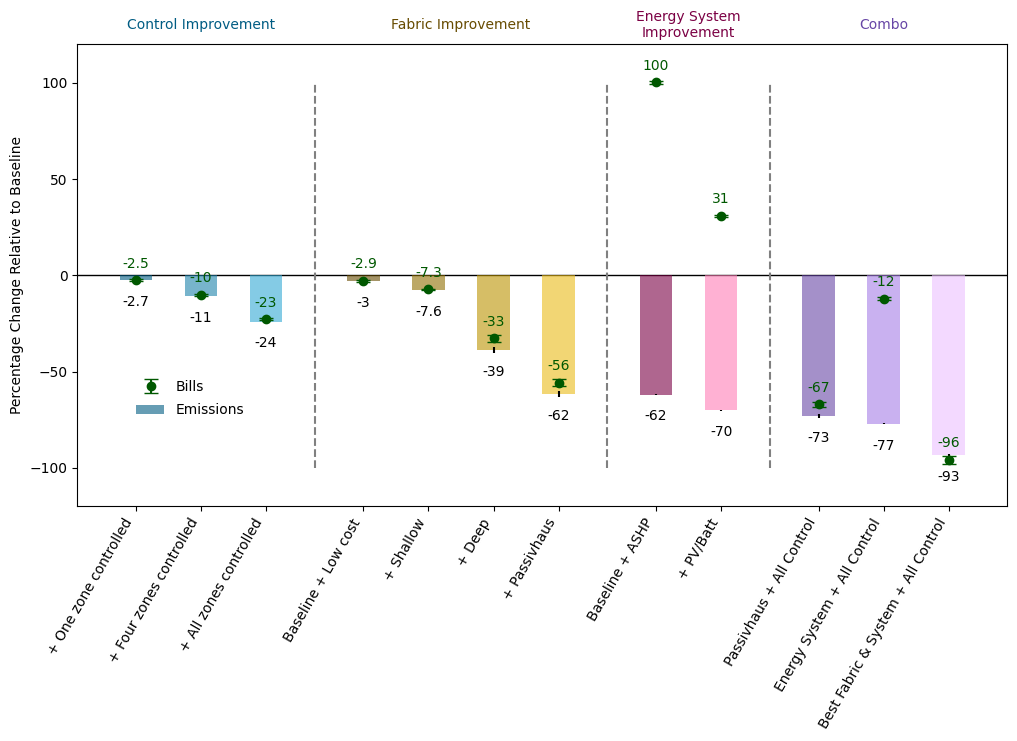

In [33]:
plot_emissions_cost_bar(merged_df)

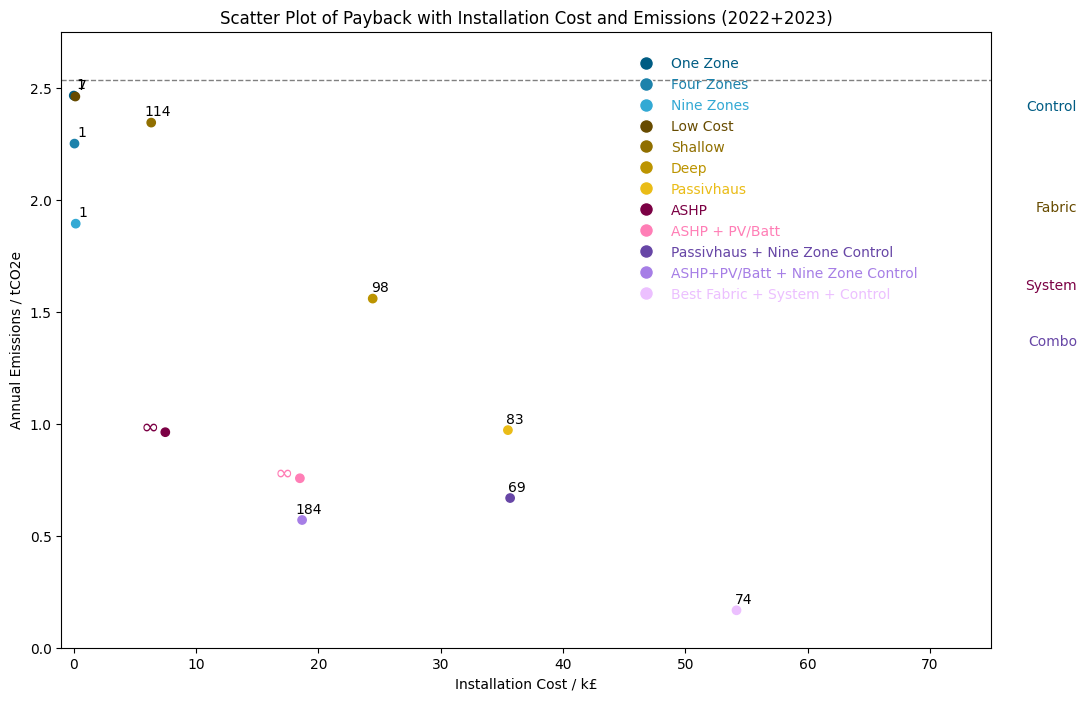

In [34]:
plot_emissions_cost_scatter(merged_df)

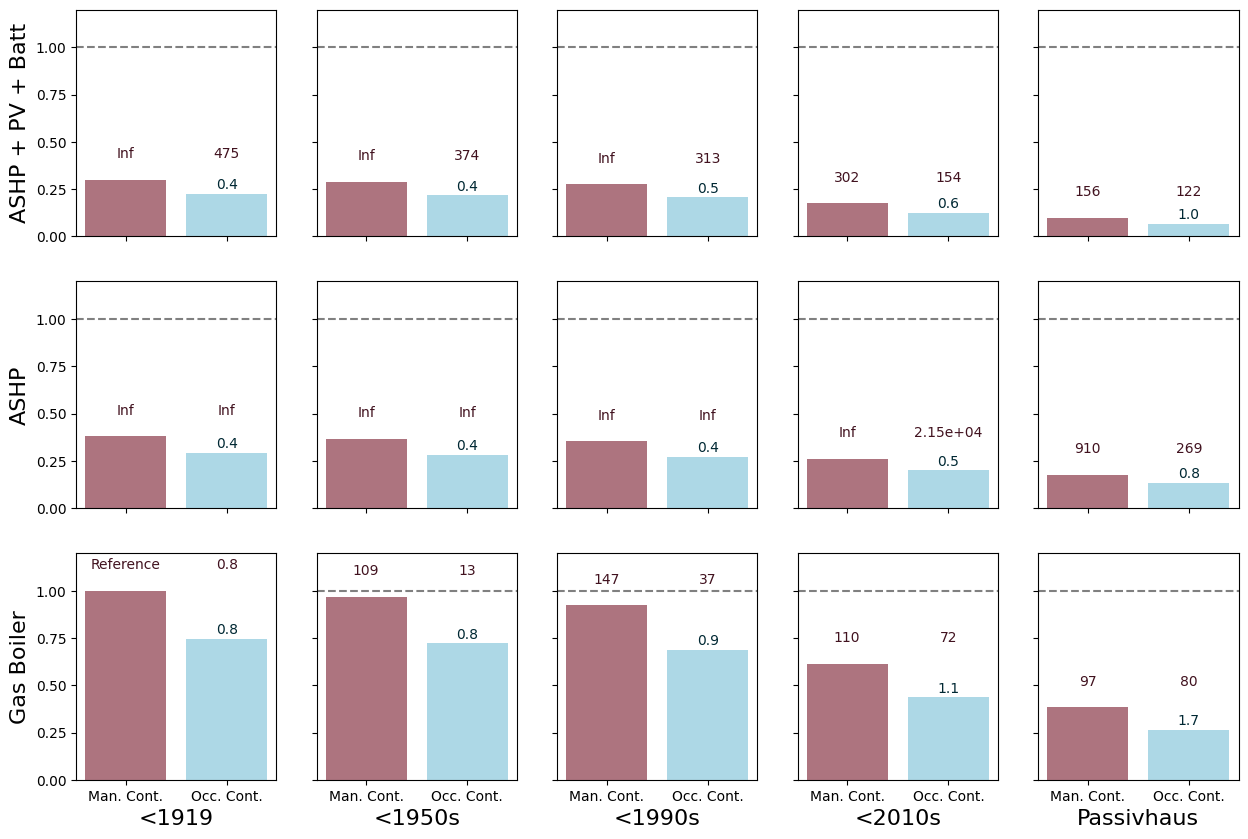

In [219]:
plot_emission_subplots(test)

In [172]:
def produce_emission_cost_contour(dataframe, temp):
    dataframe = dataframe[
        [
            "case",
            "rep",
            "zone",
            "pattern",
            "comforttemp",
            "mean_episode_cost",
            "mean_episode_emissions",
            'building_cost',
            'sensing_cost',
            'eval/air_temp_bin_15_to_16',
            'eval/air_temp_bin_16_to_17',
            'eval/air_temp_bin_17_to_18',
            'eval/air_temp_bin_18_to_19',
            'eval/air_temp_bin_19_to_20',
            'eval/air_temp_bin_20_to_21',
            'eval/air_temp_bin_21_to_22',
            'eval/air_temp_bin_22_to_23',
            'eval/air_temp_bin_23_to_24',
            'eval/air_temp_bin_24_to_30',
            'eval/opr_temp_bin_15_to_16',
            'eval/opr_temp_bin_16_to_17',
            'eval/opr_temp_bin_17_to_18',
            'eval/opr_temp_bin_18_to_19',
            'eval/opr_temp_bin_19_to_20',
            'eval/opr_temp_bin_20_to_21',
            'eval/opr_temp_bin_21_to_22',
            'eval/opr_temp_bin_22_to_23',
            'eval/opr_temp_bin_23_to_24',
            'eval/opr_temp_bin_24_to_30'
        ]
    ]

    fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(28, 44), sharex=False, sharey=True)

    heating_patterns = sorted(dataframe["pattern"].unique(), reverse=True)
    cases = [0, 1, 2, 3, 4]
    setback_temp = 16

    global_min_comfort, global_max_comfort = -50, 20
    levels_emissions = np.arange(-100, 110, 10)

    custom_levels_comfort = [-30, -20,-15, -10,-5, -1, 1, 5, 10, 15, 20, 30]#[-50, -40, -30, -20, -10,-5, -1, 1, 5, 10, 15, 20]
    custom_colours = ['#A50026', '#DD3D2D','#F67E4B', '#FDB366', '#FEDA8B', '#FFFFFF','#C2E4EF','#98CAE1',  '#6EA6CD','#4A7BB7', '#364B9A'  ] #'#50bff1', '#529ff5', '#4c80f9', '#3a5ffc'  ]#['#003200', '#004903', '#056005', '#15790e', '#2b911e', '#45aa34', '#f1f1f1', '#F7F056', '#F6C141', '#F4A736', '#E8601C']

    case_names = {0: "<1919", 1: "1950s", 2: "1990s", 3: "2010s", 4: "Passivhaus"}

    contourf_plots = []

    for row, case in enumerate(cases):
        for col, heating_pattern in enumerate(heating_patterns):
            ax = axes[row, col]

            df_0 = dataframe[
                (dataframe["case"] == case) &
                (dataframe["zone"] == 0) &
                (dataframe["rep"] == 1) &
                (dataframe["pattern"] == heating_pattern)
            ]

            df_9 = dataframe[
                (dataframe["case"] == case) &
                (dataframe["rep"] == 1) &
                (dataframe["zone"] == 9) &
                (dataframe["pattern"] == heating_pattern)
            ]

            emissions_data = {}
            cost_data = {}
            comfort_data = {}

            for i, entry_0 in df_0.iterrows():
                for j, entry_9 in df_9.iterrows():
                    emissions_reduction = ((entry_0['mean_episode_emissions'] - entry_9['mean_episode_emissions']) / entry_0['mean_episode_emissions']) * 100
                    emissions_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = emissions_reduction

                    cost_reduction = ((entry_0['mean_episode_cost'] - entry_9['mean_episode_cost']) / entry_0['mean_episode_cost']) * 100
                    cost_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = cost_reduction

                    comfort_level = int(entry_0['comforttemp'])

                    if comfort_level == 17:
                        temp_bins = ['15_to_16', '16_to_17']
                    elif comfort_level == 18:
                        temp_bins = ['15_to_16', '16_to_17', '17_to_18']
                    elif comfort_level == 19:
                        temp_bins = ['15_to_16', '16_to_17', '17_to_18', '18_to_19']
                    elif comfort_level == 20:
                        temp_bins = ['15_to_16', '16_to_17', '17_to_18', '18_to_19', '19_to_20']
                    elif comfort_level == 21:
                        temp_bins = ['15_to_16', '16_to_17', '17_to_18', '18_to_19', '19_to_20', '20_to_21']
                    elif comfort_level == 22:
                        temp_bins = ['15_to_16', '16_to_17', '17_to_18', '18_to_19', '19_to_20', '20_to_21', '21_to_22']
                    elif comfort_level == 23:
                        temp_bins = ['15_to_16', '16_to_17', '17_to_18', '18_to_19', '19_to_20', '20_to_21', '21_to_22', '22_to_23']

                    if temp == "air":
                        cbar_label = "Air"
                        entry_0['comfort_level'] = sum([entry_0[f'eval/air_temp_bin_{bin}'] for bin in temp_bins])
                        entry_9['comfort_level'] = sum([entry_9[f'eval/air_temp_bin_{bin}'] for bin in temp_bins])
                    elif temp == "opr":
                        cbar_label = "Operative"
                        entry_0['comfort_level'] = sum([entry_0[f'eval/opr_temp_bin_{bin}'] for bin in temp_bins])
                        entry_9['comfort_level'] = sum([entry_9[f'eval/opr_temp_bin_{bin}'] for bin in temp_bins])

                    comfort_change = entry_9['comfort_level'] - entry_0['comfort_level']
                    comfort_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = comfort_change

            # Create DataFrames for contour plotting
            emissions_contour_df = pd.DataFrame.from_dict(emissions_data, orient='index', columns=['emissions_reduction']).reset_index()
            emissions_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(emissions_contour_df['index'].tolist(), index=emissions_contour_df.index)
            emissions_contour_df = emissions_contour_df.drop(columns=['index'])

            cost_contour_df = pd.DataFrame.from_dict(cost_data, orient='index', columns=['cost_reduction']).reset_index()
            cost_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(cost_contour_df['index'].tolist(), index=cost_contour_df.index)
            cost_contour_df = cost_contour_df.drop(columns=['index'])

            comfort_contour_df = pd.DataFrame.from_dict(comfort_data, orient='index', columns=['comfort_change']).reset_index()
            comfort_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(comfort_contour_df['index'].tolist(), index=comfort_contour_df.index)
            comfort_contour_df = comfort_contour_df.drop(columns=['index'])

            # Find the interpolated comforttemp for comfort_change = 0
            interp_comforttemp = find_control_temp_for_manual_20_and_comfort_band(comfort_contour_df)

            # Pivot the data for contour plots
            emissions_plot_data = emissions_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="emissions_reduction")
            cost_plot_data = cost_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="cost_reduction")
            comfort_plot_data = comfort_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="comfort_change")

            X, Y = np.meshgrid(emissions_plot_data.columns, emissions_plot_data.index)
            Z = emissions_plot_data.values
            Z_comfort = comfort_plot_data.values

            X_cost, Y_cost = np.meshgrid(cost_plot_data.columns, cost_plot_data.index)
            Z_cost = cost_plot_data.values

            contourf_plot = ax.contourf(X, Y, Z_comfort, extend='both', levels=custom_levels_comfort, colors=custom_colours)
            contourf_plots.append(contourf_plot)
            contours_cost = ax.contour(X_cost, Y_cost, Z_cost, colors='white', linewidths=0.5, levels=levels_emissions)
            contours = ax.contour(X, Y, Z, colors='black', linewidths=0.5, levels=levels_emissions)

            emission_labels = ax.clabel(contours, inline=True, fontsize=16, fmt="%.0f%%")
            cost_labels = ax.clabel(contours_cost, inline=True, fontsize=16, fmt="%.0f%%")

            for label in cost_labels:
                label.set_fontweight('bold')

            if interp_comforttemp is not None:
                ax.plot(20, interp_comforttemp, 'o', markersize=8, markerfacecolor='none', markeredgecolor='black', markeredgewidth=2)

                # Interpolate the cost reduction at this comforttemp
                df_filtered_cost = cost_contour_df[cost_contour_df['comforttemp_zone0'] == 20].sort_values(by='comforttemp_zone9')

                if not df_filtered_cost.empty:
                    below = df_filtered_cost[df_filtered_cost['comforttemp_zone9'] <= interp_comforttemp].iloc[-1]
                    above = df_filtered_cost[df_filtered_cost['comforttemp_zone9'] >= interp_comforttemp].iloc[0]

                    # Linear interpolation
                    cost_reduction_at_point = below['cost_reduction'] + (interp_comforttemp - below['comforttemp_zone9']) * (above['cost_reduction'] - below['cost_reduction']) / (above['comforttemp_zone9'] - below['comforttemp_zone9'])

                    ax.annotate(f'{cost_reduction_at_point:.0f}%', xy=(20, interp_comforttemp), xytext=(10, 10),
                                textcoords='offset points', color='black', fontsize=16, weight='bold')
            else:
                print("No valid interpolation found for comfort_change = 0.")

            for tick in np.arange(X.min(), X.max() + 1, 1):
                ax.axvline(tick, color='grey', linestyle='--', linewidth=0.5)
            for tick in np.arange(Y.min(), Y.max() + 1, 1):
                ax.axhline(tick, color='grey', linestyle='--', linewidth=0.5)

            if row == 0:
                if col == 0:
                    ax.set_title("Heating Hours\n  6-8 + 12-14 + 18-23", fontsize=24)
                elif col == 1:
                    ax.set_title("Heating Hours\n  6-9 + 16-23", fontsize=24)
                elif col == 2:
                    ax.set_title("Heating Hours\n 6-23", fontsize=24)

            if col == 0:
                ax.set_ylabel(f"Case: {case_names[case]}", fontsize=24)

            ax.tick_params(axis='both', which='major', labelsize=20)
            ax.set_xticks(np.arange(X.min(), X.max() + 1, 1))
            ax.set_yticks(np.arange(Y.min(), Y.max() + 1, 1))


    cbar = fig.colorbar(contourf_plot, ax=axes, orientation='vertical',
                    ticks=custom_levels_comfort, fraction=0.04, pad=0.04)

    # Invert the colour bar
    cbar.ax.invert_yaxis()
    # Change the fontsize of the colour bar ticks
    cbar.ax.tick_params(labelsize=16)

    cbar.set_label(f"Change in Time spent below the Manually Set Comfort Temperature ({cbar_label})  (%)", fontsize=20)

    fig.text(0.05, 0.5, 'Occupancy-Control Thermostat Temperature', va='center', rotation='vertical', fontsize=24)
    fig.text(0.5, 0.09, 'Manually Set Thermostat Temperature', ha='center', rotation='horizontal', fontsize=24)

    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/cost_comfort_contour_plot.svg")

    plt.show()



def find_control_temp_for_manual_20_and_comfort_band(comfort_df):
    df_filtered = comfort_df[comfort_df['comforttemp_zone0'] == 20].sort_values(by='comforttemp_zone9')

    # Find all intervals where the comfort_change crosses zero
    crossing_points = []
    for i in range(len(df_filtered) - 1):
        if df_filtered.iloc[i]['comfort_change'] > 0 and df_filtered.iloc[i + 1]['comfort_change'] < 0:
            crossing_points.append((df_filtered.iloc[i], df_filtered.iloc[i + 1]))
        elif df_filtered.iloc[i]['comfort_change'] < 0 and df_filtered.iloc[i + 1]['comfort_change'] > 0:
            crossing_points.append((df_filtered.iloc[i], df_filtered.iloc[i + 1]))

    if not crossing_points:
        return None

    # Interpolate for all crossing points and return the average or a single point based on criteria
    interpolated_comforttemps = []
    for below, above in crossing_points:
        comforttemp_0 = below['comforttemp_zone9'] + (0 - below['comfort_change']) * (above['comforttemp_zone9'] - below['comforttemp_zone9']) / (above['comfort_change'] - below['comfort_change'])
        interpolated_comforttemps.append(comforttemp_0)

    # Return the average of all interpolated comforttemps if there are multiple crossings
    return sum(interpolated_comforttemps) / len(interpolated_comforttemps)


No valid interpolation found for comfort_change = 0.
No valid interpolation found for comfort_change = 0.


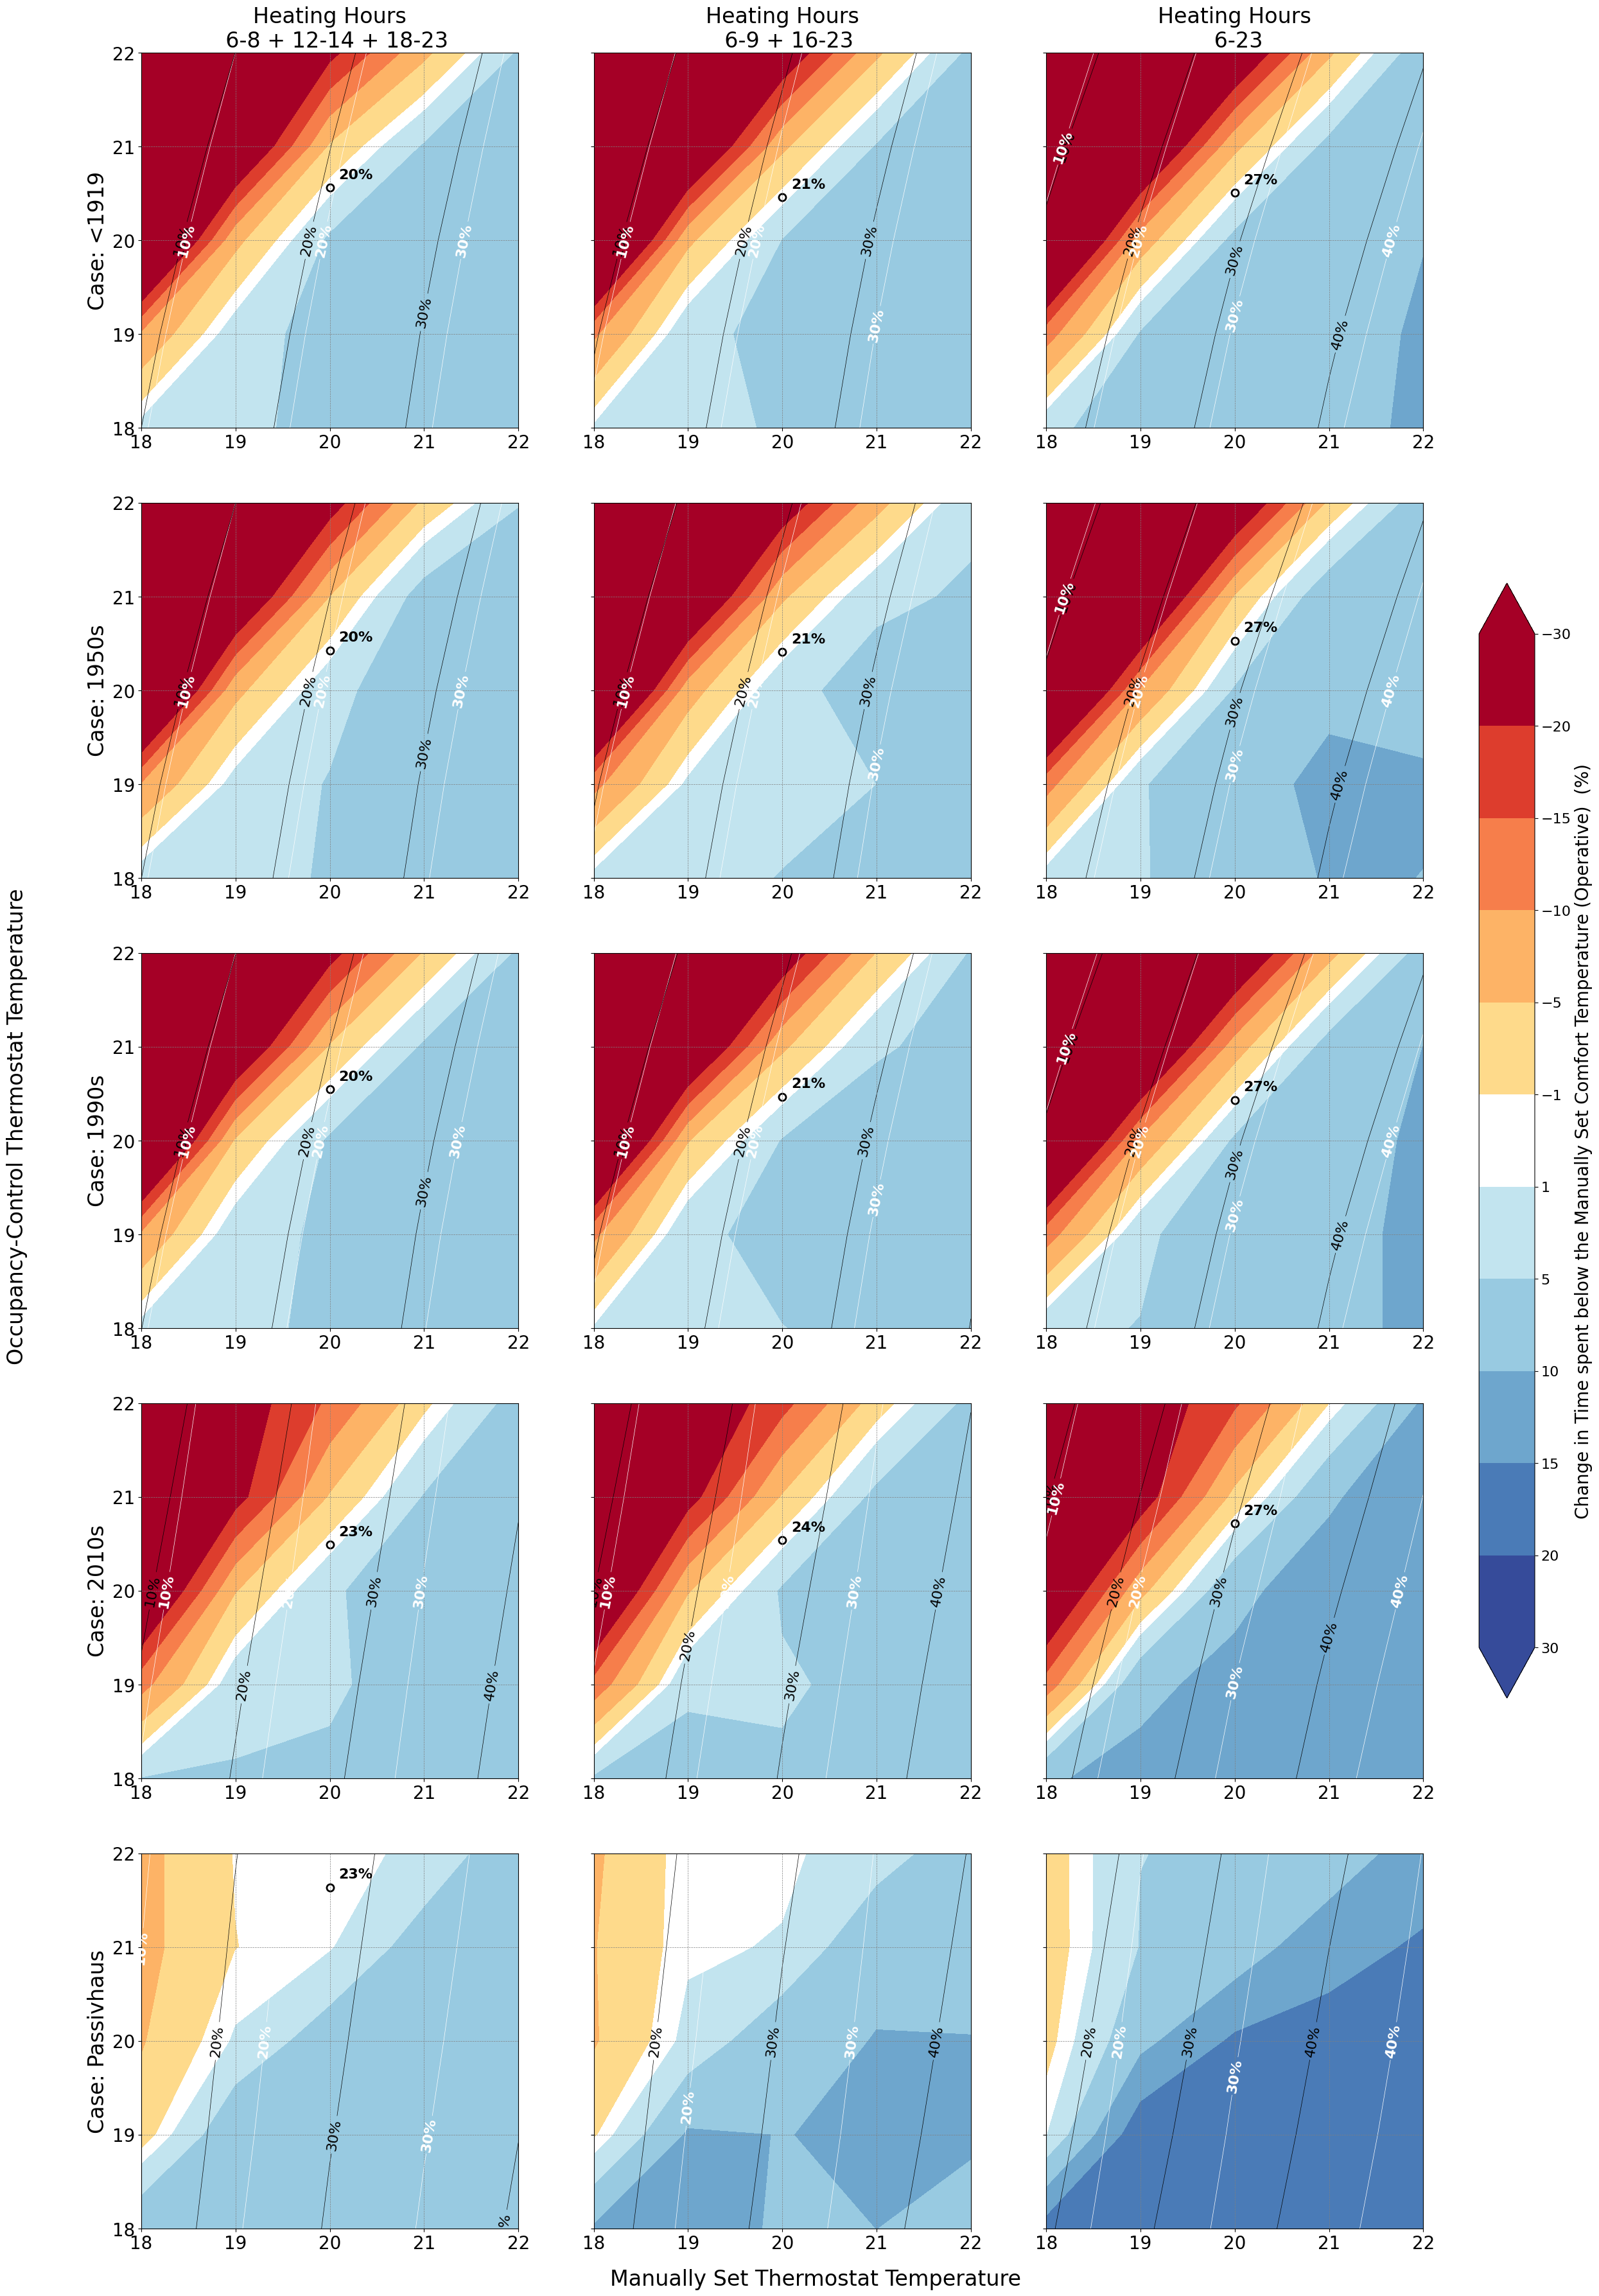

In [173]:
results_df = pd.read_csv("combined_results_df.csv")
#temperature_df = pd.read_csv("combined_temperature_df.csv")

results_df = pd.merge(results_df, building_cost_df, on='case', how='left')
results_df = pd.merge(results_df, sensing_cost_df, on='zone', how='left')
results_df = pd.merge(results_df, case_names_df, on='case', how='left')

emissions = produce_emission_cost_contour(results_df, temp="opr")